# Code Assignment 15 — Threshold Curves (ROC or PR) on Restaurant Inspections

**Format:** Instructor Guidance → Your Task (step-by-step) → We Share (reflection)

**Goal:** Build a **new** classification model (use **at least 2 features**) on NYC **Restaurant Inspection Results**. Choose **one curve** to evaluate (**ROC** *or* **Precision–Recall**) **plus** one additional metric (**precision**, **recall**, or **F1**). Justify your choice based on class imbalance and business costs.

> Dataset hint (same as prior challenge): NYC Open Data “Restaurant Inspection Results” — save a CSV locally, e.g. `./data/nyc_restaurant_inspections.csv`. Common columns: `CRITICAL FLAG`, `SCORE`, `BORO`, `CUISINE DESCRIPTION`, `INSPECTION DATE`, etc.


## Instructor Guidance (Pseudocode + Docs)

**Docs:**
- Train/test split — scikit-learn: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html  
- Logistic Regression — scikit-learn: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html  
- ROC / AUC — scikit-learn: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_curve.html  
- Precision–Recall — scikit-learn: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_recall_curve.html  
- Classification report — scikit-learn: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html  
- `get_dummies` — pandas: https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.get_dummies.html

### Pseudocode Plan
1) **Load CSV** → preview columns/shape.  
2) **Target (y)**: `CRITICAL FLAG == "CRITICAL"` → 1 else 0; check class balance.  
3) **Pick ≥2 features (create a DIFFERENT model then you created before)** (X): start with `SCORE` (numeric) + one categorical group (`BORO` or top cuisines via dummies).  
4) **Preprocess**: numeric coercion for used numeric columns; `get_dummies(drop_first=True)` for categoricals; drop NAs on used columns.  
5) **Split**: `train_test_split(..., stratify=y, random_state=42)`.  
6) **Fit**: `LogisticRegression(max_iter=1000)` on train.  
7) **Evaluate curves**:  
   - If **ROC**: use `predict_proba()[:,1]` → `roc_curve`, compute **AUC**.  
   - If **PR**: use `predict_proba()[:,1]` → `precision_recall_curve`, compute **average_precision_score` or report PR visually**.  
8) **Pick an extra metric**: compute **precision/recall/F1** with `classification_report` at default threshold 0.5 (or optionally choose a custom threshold -- which is IDEAL).  
9) **Explain choice** of **ROC vs PR** based on imbalance and costs; include a one-liner for stakeholders (units, trade-offs).


## Your Task — Step-by-Step
Work in pairs. Comment decisions briefly. Keep code minimal and readable.


### 1) Load the CSV & Preview


In [15]:
import pandas as pd, numpy as np
import statsmodels.api as sm
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import dataprep
from sklearn.model_selection import train_test_split
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler , OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix



pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 200)

In [19]:
df = pd.read_csv('/Users/Marcy_Student/Downloads/DOHMH_New_York_City_Restaurant_Inspection_Results_20251104 copy.csv')


df.head()

data = df[['SCORE','CRITICAL FLAG','BORO']]
df.dtypes
data.dtypes
data.shape
display(data.head(10))
#data['INSPECTION TYPE'].value_counts()
df.head()

,SCORE,CRITICAL FLAG,BORO
0,NaN,Not Applicable,Queens
1,NaN,Not Applicable,Brooklyn
2,NaN,Not Applicable,Queens
3,NaN,Not Applicable,Queens
4,NaN,Not Applicable,Brooklyn
5,NaN,Not Applicable,Manhattan
6,NaN,Not Applicable,Manhattan
7,NaN,Not Applicable,Manhattan
8,NaN,Not Applicable,Manhattan
9,NaN,Not Applicable,Queens


,CAMIS,DBA,BORO,BUILDING,STREET,ZIPCODE,PHONE,CUISINE DESCRIPTION,INSPECTION DATE,ACTION,VIOLATION CODE,VIOLATION DESCRIPTION,CRITICAL FLAG,SCORE,GRADE,GRADE DATE,RECORD DATE,INSPECTION TYPE,Latitude,Longitude,Community Board,Council District,Census Tract,BIN,BBL,NTA,Location
0,50174196,THE GREATS OF CRAFT,Queens,47-20,CENTER BOULEVARD,"11,109.0000",3479312023,NaN,01/01/1900,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaN,11/03/2025,NaN,40.7456,-73.9571,402.0000,26.0000,100.0000,"4,538,318.0000","4,000,210,070.0000",QN31,POINT (-73.957136627525 40.745640668157)
1,50140563,CANTEEN @ CHELSEA PIERS FIELD HOUSE,Brooklyn,601,DEAN STREET,"11,238.0000",6313880993,NaN,01/01/1900,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaN,11/03/2025,NaN,40.6806,-73.9700,308.0000,35.0000,"16,300.0000","3,428,601.0000","3,000,000,000.0000",BK64,POINT (-73.969992200023 40.68061568349)
2,50177123,70 7TH AVENUE SOUTH THEROS LLC,Queens,3009,35TH ST,"11,103.0000",6468076482,NaN,01/01/1900,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaN,11/03/2025,NaN,40.7648,-73.9187,401.0000,22.0000,"6,300.0000","4,009,926.0000","4,006,500,041.0000",QN70,POINT (-73.918674354617 40.764778282908)
3,50001285,Y & B ENTERTAINMENT MANOR,Queens,3509,PRINCE STRRET,NaN,7188881778,Korean,06/24/2018,Violations were cited in the following area(s).,15F6,Workplace SFAA policy not prominently posted i...,Not Applicable,NaN,NaN,NaN,11/03/2025,Smoke-Free Air Act / Initial Inspection,0.0000,0.0000,NaN,NaN,NaN,NaN,4.0000,NaN,NaN
4,50172517,MAPLE CREAMERY,Brooklyn,653,STERLING PLACE,"11,216.0000",7188095106,NaN,01/01/1900,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaN,11/03/2025,NaN,40.6733,-73.9568,308.0000,35.0000,"21,900.0000","3,031,390.0000","3,012,380,001.0000",BK61,POINT (-73.956830036833 40.673255481805)


### 2) Define the Binary Target (y)
- Positive class = **Critical** violation.

In [20]:
data['critical'] = (data['CRITICAL FLAG'] == 'Critical').astype(int)

/var/folders/bs/gtwb0lj97nb4v95968dmfzww0000gp/T/ipykernel_41608/237272631.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['critical'] = (data['CRITICAL FLAG'] == 'Critical').astype(int)


### 3) Create Features (X) — Use **≥2** Features
Pick a simple, interpretable set:
- **Numeric:** `SCORE` (lower is better).
- **Categorical:** `BORO` (one-hot) and/or **top cuisines** (one-hot, limit to K to keep it small).

> If any column is missing, adapt by choosing other available columns.


In [ ]:
data = data.dropna()
data.isna().value_counts()
data.isnull().sum()
data.head()

# Checking imbalance
classes = data.groupby('critical')['SCORE'].count()

# picking my variables
x1 = data['SCORE']
x2 = data ['BORO']
y = data['critical']

Xs = data[['SCORE','BORO']]

print(classes)

critical
0    120954
1    153985
Name: SCORE, dtype: int64


### 4) Train–Test Split (Stratified)

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    Xs, y,
    test_size=0.3,
    random_state= 42,
    shuffle = True,
    stratify = y
)

### 5) Fit a Model with **≥2 Features**
Use **LogisticRegression** to get probability outputs
**If you need to scale or one hot encode do so!**


In [36]:
# transform categorical variable with one hot dog and scaling score
preprocessing = ColumnTransformer(
    transformers=[
        ('numerical', StandardScaler(), ['SCORE']),
        ('categorical', OneHotEncoder(handle_unknown='ignore',drop='first'), ['BORO'])
        ]
        )

my_pipeline = Pipeline(steps=[
    ('Process', preprocessing),
    ('logistic_model',LogisticRegression())
])

display(my_pipeline)

# fitting the model
model = my_pipeline.fit(X_train, y_train)

#predictions
y_prediction = my_pipeline.predict(X_test)
print(y_prediction)


Pipeline(steps=[('Process',
                 ColumnTransformer(transformers=[('numerical', StandardScaler(),
                                                  ['SCORE']),
                                                 ('categorical',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['BORO'])])),
                ('logistic_model', LogisticRegression())])

[0 1 1 ... 1 1 0]


### 6) Choose Your Evaluation: **ROC** or **PR** Curve
Set `EVAL = 'ROC'` or `EVAL = 'PR'`. Then:
- If **ROC**: plot ROC, compute **AUC-ROC**.
- If **PR**: plot PR curve, compute **Average Precision (AP)**.
Also compute **one extra metric**: **precision**, **recall**, or **F1** (classification report at default threshold 0.5).


AUC-ROC:0.605


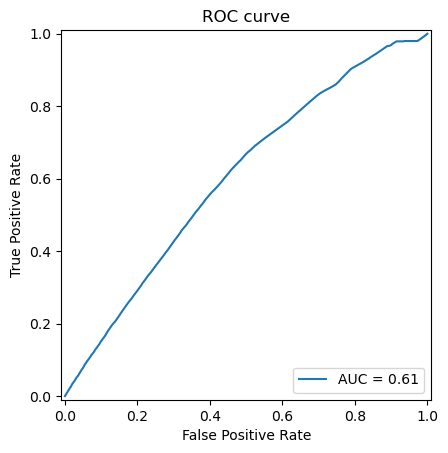

recall:0.8678673478223223
[[ 8879 27407]
 [ 6104 40092]]


In [72]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay, roc_auc_score
##
proba = model.predict_proba(X_test)[:,1]

fpr, tpr, roc_th = roc_curve(y_test, proba)
roc_auc = auc(fpr, tpr)

print(f"AUC-ROC:{roc_auc:.3f}")
RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc).plot()
plt.title('ROC curve')
plt.show()

recall= recall_score(y_test, y_prediction, zero_division=0)
print(f'recall:{recall}')
cm = confusion_matrix(y_test, y_prediction, labels=[0, 1])
print(cm)

### 7) Try a Custom Threshold -- Update the code to fit your threshold and/or variable names from previous cells
Pick a threshold from your curve (e.g., a point balancing your business needs), then recompute metrics.


Area Under the ROC Curve for threshold 0.5: 0.6054024109494812
Area Under the ROC Curve for threshold 0.7: 0.5128939753535459


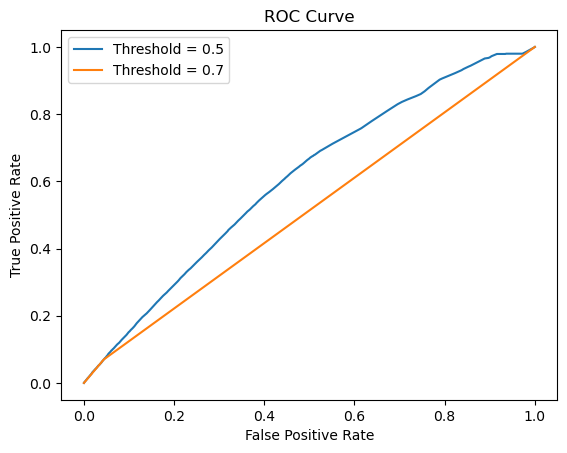

In [73]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, proba)
plt.plot(fpr, tpr,  label = 'Threshold = 0.5')
print('Area Under the ROC Curve for threshold 0.5:', roc_auc_score(y_test, proba))

# For Threshold 0.9
proba_new_threshold = (model.predict_proba(X_test)[:,1]>=0.7).astype(int)
fpr_, tpr_, thresholds_ = roc_curve(y_test, proba_new_threshold)
print('Area Under the ROC Curve for threshold 0.7:', roc_auc_score(y_test, proba_new_threshold))
plt.plot(fpr_, tpr_, label = 'Threshold = 0.7')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

## We Share — Reflection (Post 2 short paragraphs)

1) **Curve choice & results:** Which curve did you use (**ROC** or **PR**) and **why** (tie to class balance & business costs)? Report your curve summary (**AUC-ROC** or **Average Precision**) and your chosen extra metric (**precision/recall/F1**) — include threshold (0.5 or custom).  
- I chose the ROC curve because the classes are balanced enough, 120k vs 150k occurences for each class. The Area under the curve AUC is 0.61 at 50% threshold and the sensitivity of the model is 86%.
2) **Stakeholder one-liner:** In plain English: “Using **score and borough**, our model at threshold **0.5** yields **86% precision**. This means **that the model correctly predicted 86% of all critical cases**. Next, we’d **add more relevant features** to improve that sensitivity and the overall model performance.”

> Tip: If the positive class is rare, PR is often more informative than ROC. If classes are balanced or you’re comparing ranking quality across models, AUC-ROC is fine — but still report a confusion matrix at your chosen threshold.
